In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import qmax as qx

from miscutils.plot import animate

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
x0 = -10
xf = 10
num_steps = 500
#num_modes = 500

finite_difference = qx.spaces.FiniteDifference1D(x0, xf, num_steps)
#pseudo_spectral = qx.spaces.PseudoSpectral(x0, xf, num_steps, num_modes)

space2D = qx.tensor.SpatialTensorProduct((finite_difference, finite_difference))

In [3]:
X, Y = space2D.x_meshgrid

In [4]:
x0 = jnp.array([5, 5])
y_fn = lambda x: jnp.exp(-0.5 * (x - x0) @ (x - x0))
y_vals = space2D.eval(y_fn)
y = space2D.from_values(y_vals)

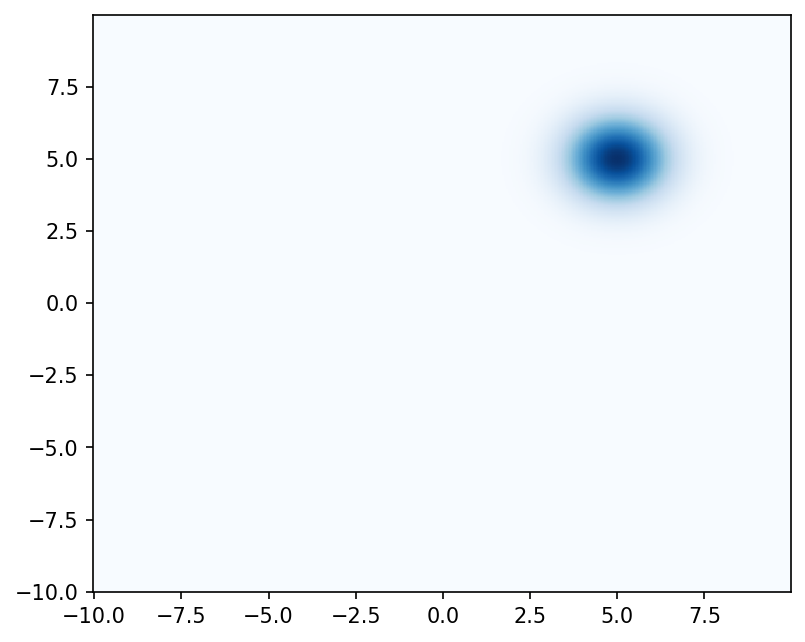

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=150)

ax.pcolormesh(X, Y, jnp.abs(y.values), cmap="Blues")

plt.show()
plt.close(fig)

In [7]:
Li = qx.spaces.FiniteDifference1DLaplacian()
T = -0.5 * qx.tensor.KroneckerSum((Li, Li))
V = qx.tensor.FiniteDifferenceTensorPotentialEnergy(lambda x: 0.5 * (x @ x), space2D)
H = T + V

In [8]:
t0, t1 = 0., 4 * jnp.pi
dt = 0.01

sys = qx.TimeInvariantSystem(H)
%time ys, t_range = sys.propagate(t0, t1, dt, y, qx.timestepper.Midpoint())

CPU times: user 24.8 s, sys: 42.8 ms, total: 24.8 s
Wall time: 24.8 s


In [9]:
def func(idx, ax, state, args):
    y_vals = ys[idx].values
    ax[0].pcolormesh(X, Y, jnp.real(y_vals),  vmin=0, vmax=1.0, cmap="Blues")
    ax[1].pcolormesh(X, Y, jnp.imag(y_vals),  vmin=0, vmax=1.0, cmap="Blues")
    
%time animate(func, t_range.shape[0] // 2, filename="output.mp4", shape=(1, 2), figsize=(6, 3))
#Image(url="output.gif")  

/usr/lib/python3.14/subprocess.py:1920: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


CPU times: user 1min 15s, sys: 1.74 s, total: 1min 17s
Wall time: 1min 17s
